In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import seaborn as sns

## Data Understanding

In [2]:
df=pd.read_csv("LUBS5990M_courseworkData_2324.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2767 non-null   int64  
 1   success                2767 non-null   object 
 2   brandSlogan            2767 non-null   object 
 3   hasVideo               2767 non-null   int64  
 4   rating                 2767 non-null   float64
 5   priceUSD               2587 non-null   float64
 6   countryRegion          2696 non-null   object 
 7   startDate              2767 non-null   object 
 8   endDate                2767 non-null   object 
 9   teamSize               2613 non-null   float64
 10  hasGithub              2767 non-null   int64  
 11  hasReddit              2767 non-null   int64  
 12  platform               2767 non-null   object 
 13  coinNum                2767 non-null   float64
 14  minInvestment          2767 non-null   int64  
 15  dist

In [4]:
df.isna().sum()

ID                         0
success                    0
brandSlogan                0
hasVideo                   0
rating                     0
priceUSD                 180
countryRegion             71
startDate                  0
endDate                    0
teamSize                 154
hasGithub                  0
hasReddit                  0
platform                   0
coinNum                    0
minInvestment              0
distributedPercentage      0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.replace(['Y','N'],[1,0],inplace=True)

In [7]:
num_col=[4,5,9,13,15]

In [8]:
df.iloc[:,num_col].describe()

,rating,priceUSD,teamSize,coinNum,distributedPercentage
count,2767.000000,2587.000000,2613.000000,2.767000e+03,2767.000000
mean,3.121323,19.014036,13.107539,8.177880e+12,1.061370
std,0.714452,775.287126,8.082433,4.300018e+14,17.485513
min,1.000000,0.000000,1.000000,1.200000e+01,0.000000
25%,2.600000,0.040000,7.000000,5.000000e+07,0.400000
50%,3.100000,0.120000,12.000000,1.800000e+08,0.550000
75%,3.700000,0.500000,17.000000,6.000000e+08,0.700000
max,4.800000,39384.000000,75.000000,2.261908e+16,869.750000


<Axes: ylabel='Frequency'>

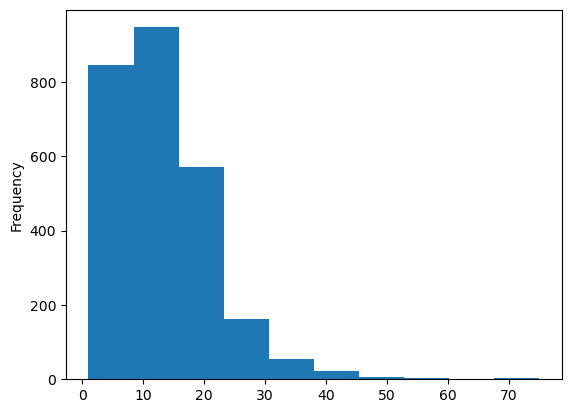

In [9]:
df.iloc[:,9].plot.hist()

rating


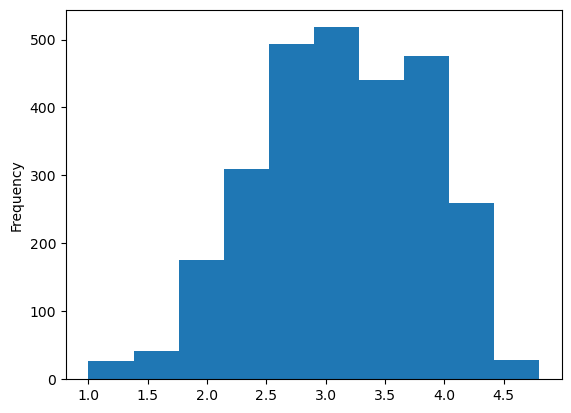

priceUSD


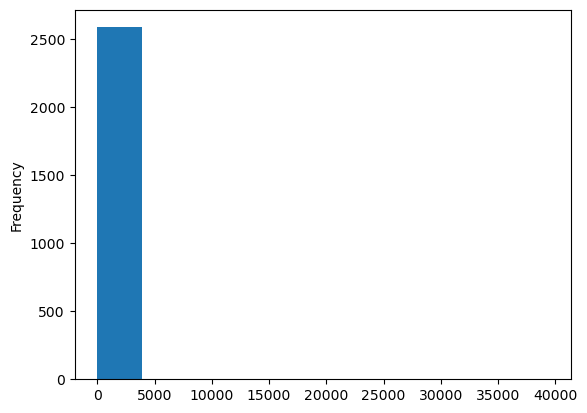

teamSize


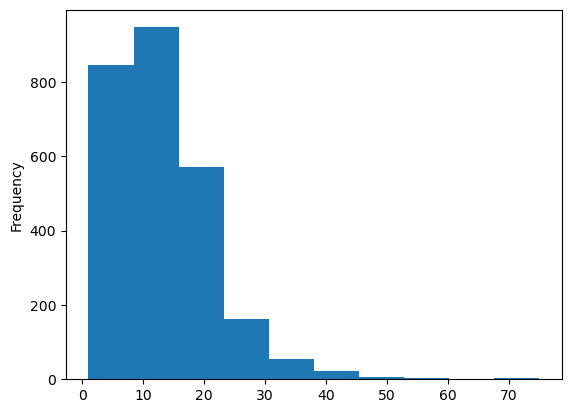

coinNum


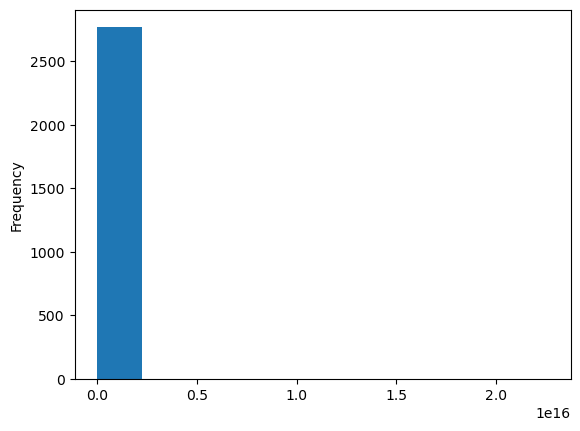

distributedPercentage


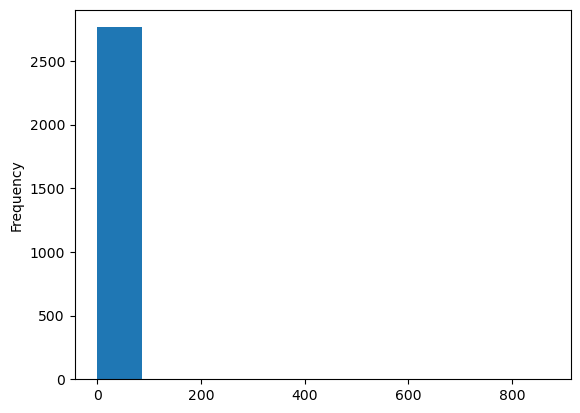

In [10]:
for x in num_col:
    print(df.columns[x])
    df.iloc[:,x].plot.hist()
    plt.show()

rating


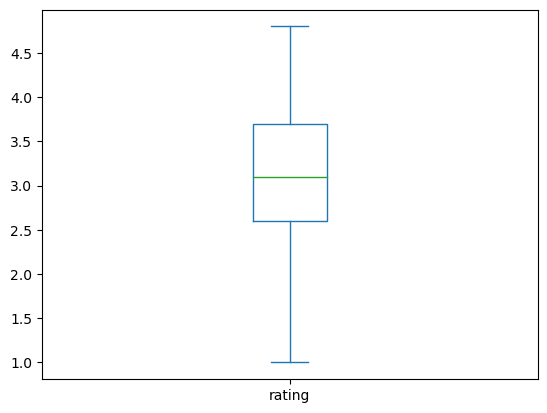

priceUSD


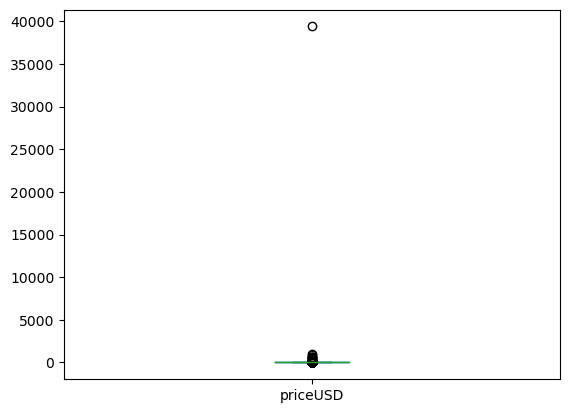

teamSize


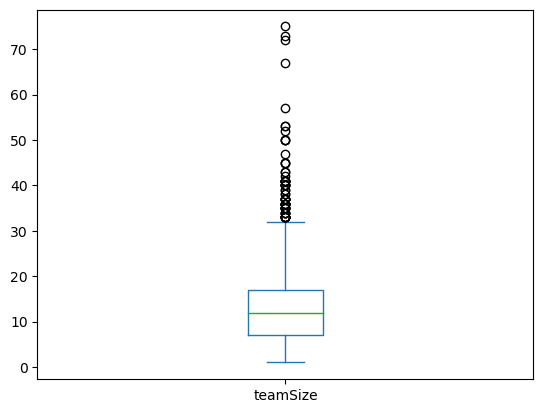

coinNum


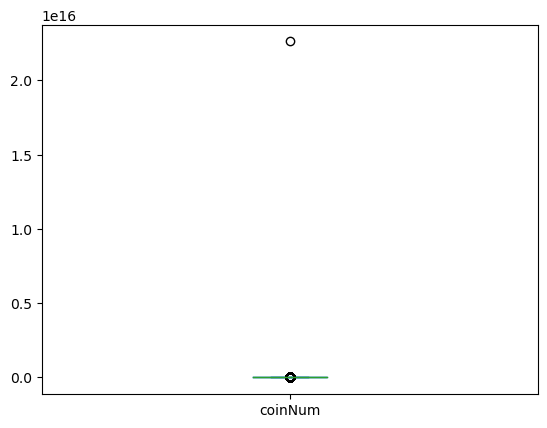

distributedPercentage


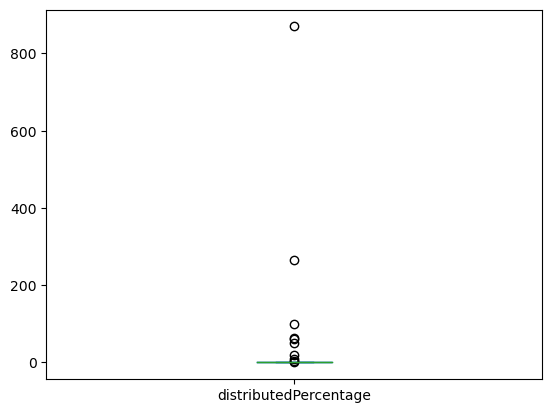

In [11]:
for x in num_col:
    print(df.columns[x])
    df.iloc[:,x].plot.box()
    plt.show()

In [12]:
cat_col=[3,6,10,11,12,14]

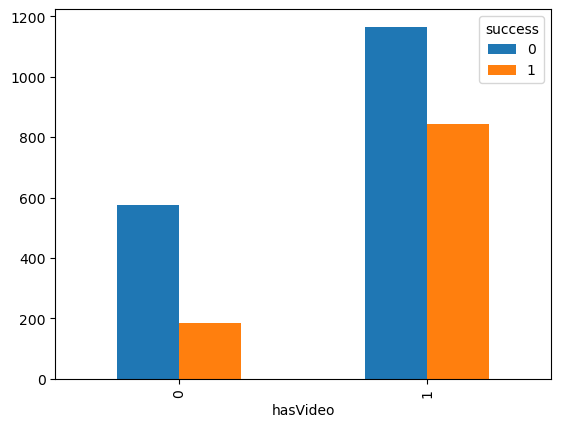

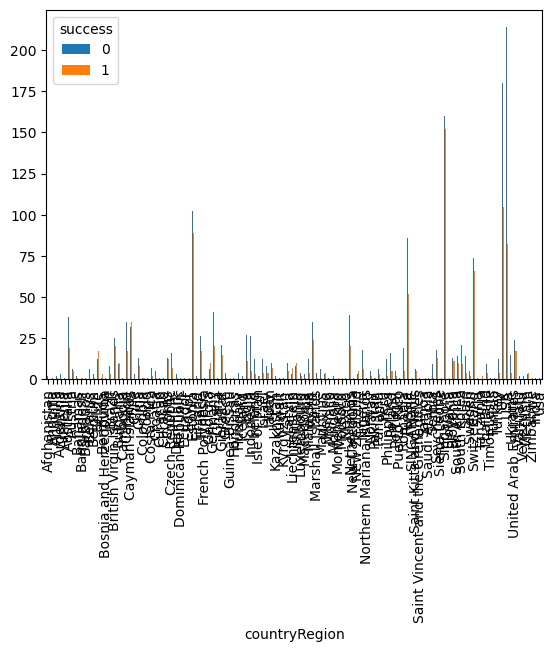

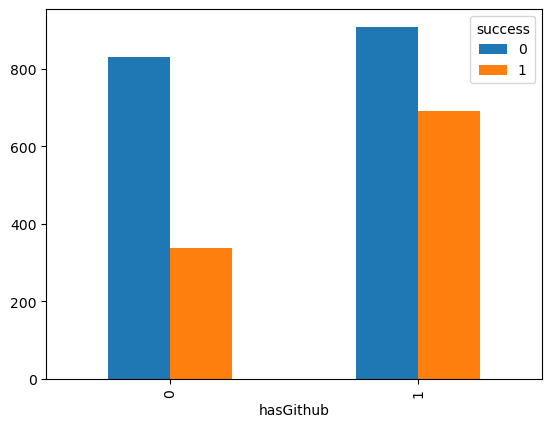

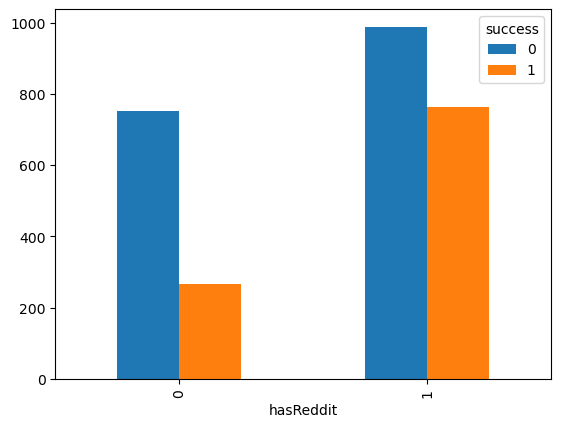

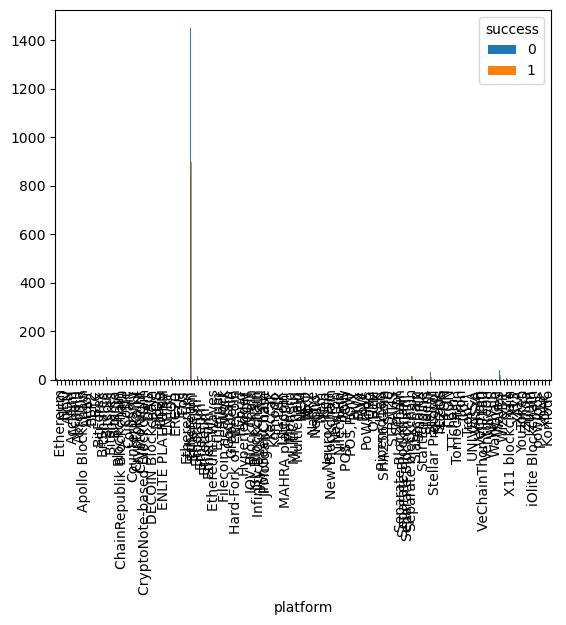

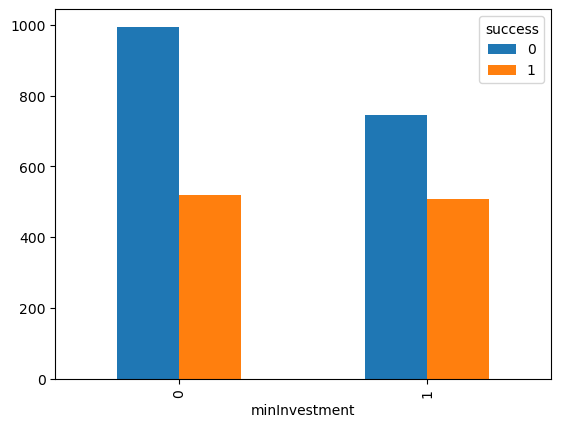

In [13]:
for x in cat_col:
    pd.crosstab(df.iloc[:,x], df['success']).plot.bar()

In [14]:
for x in cat_col:
    print(df.columns[x]," : ",len(df.iloc[:,x].unique()))
    print(df.iloc[:,x].value_counts())

hasVideo  :  2
hasVideo
1    2009
0     758
Name: count, dtype: int64
countryRegion  :  121
countryRegion
Singapore        312
USA              296
UK               285
Estonia          191
Switzerland      140
                ... 
SINGAPORE          1
Syria              1
New Caledonia      1
Curaçao            1
Honduras           1
Name: count, Length: 120, dtype: int64
hasGithub  :  2
hasGithub
1    1599
0    1168
Name: count, dtype: int64
hasReddit  :  2
hasReddit
1    1751
0    1016
Name: count, dtype: int64
platform  :  130
platform
Ethereum               2352
Waves                    56
Stellar                  41
Separate blockchain      30
Ethereum                 23
                       ... 
Wanchain                  1
Lisk                      1
WizeBit                   1
Ardor                     1
WAVES                     1
Name: count, Length: 130, dtype: int64
minInvestment  :  2
minInvestment
0    1513
1    1254
Name: count, dtype: int64


<Axes: >

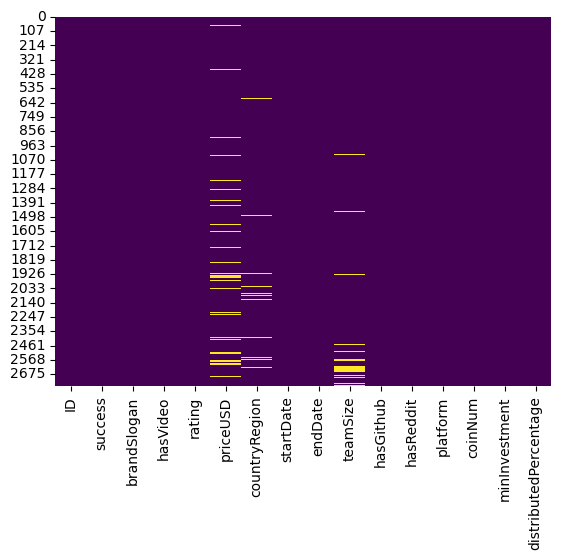

In [15]:
sns.heatmap(df.isnull(), cmap='viridis', cbar=False)

# Data Preparation

## Numeric

### Log Transform - PriceUSD and CoinNum

In [16]:
def log_t(x):
    return np.log10(x+1)

In [17]:
price_log=df.priceUSD.apply(log_t)

In [18]:
price_log.describe()

count    2587.000000
mean        0.156962
std         0.317232
min         0.000000
25%         0.017033
50%         0.049218
75%         0.176091
max         4.595331
Name: priceUSD, dtype: float64

<Axes: ylabel='Frequency'>

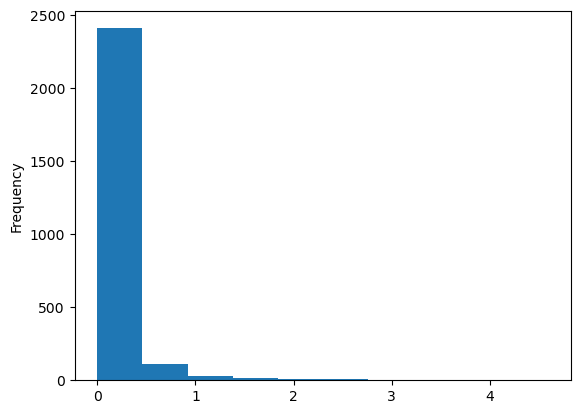

In [19]:
price_log.plot.hist()

<Axes: ylabel='Frequency'>

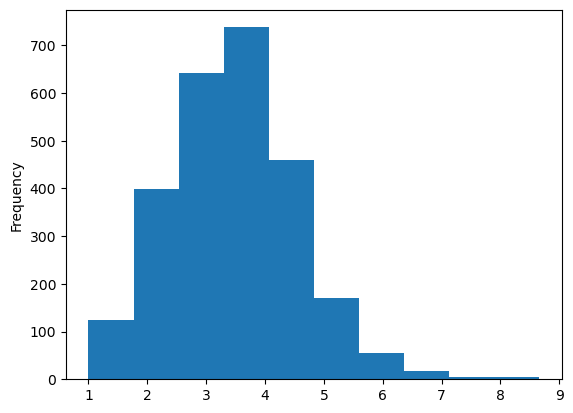

In [20]:
df.teamSize.apply(np.sqrt).plot.hist()

In [21]:
custom_bins = [0, 1, 2, 3, 9, 99, 999, 50000]

In [22]:
df_price_bins = pd.cut(df['priceUSD'], bins=custom_bins, right=True, include_lowest=True)

In [23]:
df_price_bins.value_counts()

priceUSD
(-0.001, 1.0]       2314
(1.0, 2.0]           113
(3.0, 9.0]            56
(9.0, 99.0]           44
(2.0, 3.0]            40
(99.0, 999.0]         18
(999.0, 50000.0]       2
Name: count, dtype: int64

In [24]:
df.loc[:,'priceUSD']=df.loc[:,'priceUSD'].apply(log_t)

In [25]:
df.loc[:,'coinNum']=df.loc[:,'coinNum'].apply(log_t)

<Axes: ylabel='Frequency'>

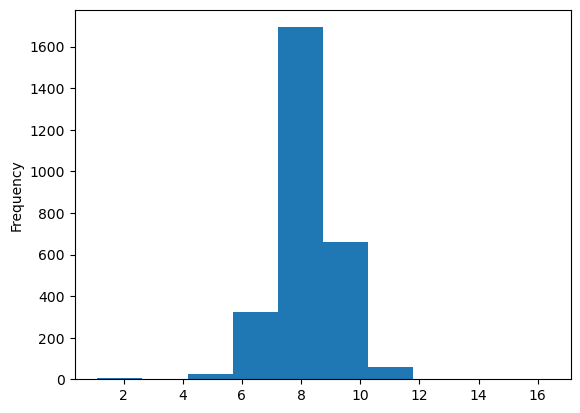

In [26]:
df.coinNum.plot.hist()

### Rescale/Remove - DistributedPercentage

In [27]:
df_distPer=df[df['distributedPercentage']>1].distributedPercentage

In [28]:
def count_digit(x):
    x=str(x)
    if '.' in x:
        x=x.split('.')
        x=x[0]
        if(len(x)==2):
            return True
    return False

In [29]:
df_distPer=df_distPer.apply(count_digit)
df_distPer

98      False
541     False
680     False
946      True
964     False
1029    False
1403     True
1407    False
1655     True
1987     True
Name: distributedPercentage, dtype: bool

In [30]:
distPer_drop=df_distPer[df_distPer==False].index
distPer_drop

Index([98, 541, 680, 964, 1029, 1407], dtype='int64')

In [31]:
df.drop(labels=distPer_drop,inplace=True)

In [32]:
distPer_rescale=df_distPer[df_distPer==True].index
distPer_rescale

Index([946, 1403, 1655, 1987], dtype='int64')

In [33]:
df.loc[distPer_rescale,'distributedPercentage']=df.loc[distPer_rescale,'distributedPercentage']/100

In [34]:
df.iloc[:,num_col].describe()

,rating,priceUSD,teamSize,coinNum,distributedPercentage
count,2761.000000,2582.000000,2607.000000,2761.000000,2761.000000
mean,3.120355,0.156794,13.117760,8.228598,0.541490
std,0.714735,0.317399,8.088223,1.009182,0.212284
min,1.000000,0.000000,1.000000,1.113943,0.000000
25%,2.600000,0.017033,7.000000,7.698970,0.400000
50%,3.100000,0.049218,12.000000,8.255273,0.550000
75%,3.700000,0.176091,17.000000,8.778151,0.700000
max,4.800000,4.595331,75.000000,16.354475,1.000000


rating


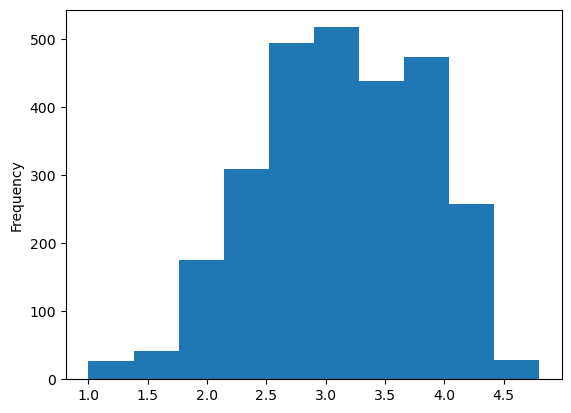

priceUSD


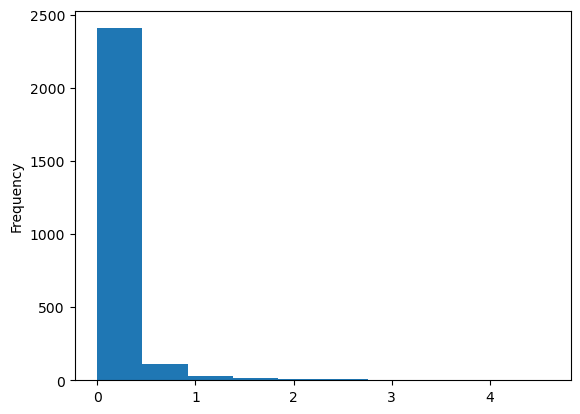

teamSize


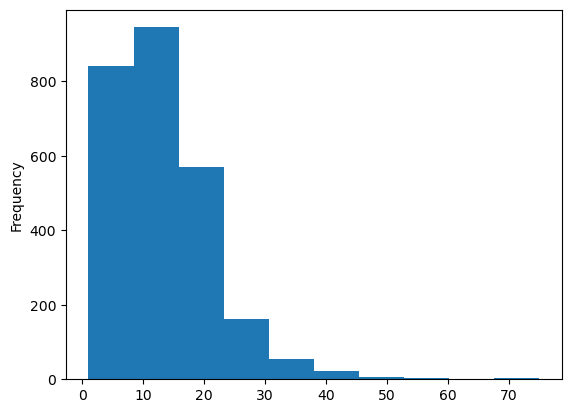

coinNum


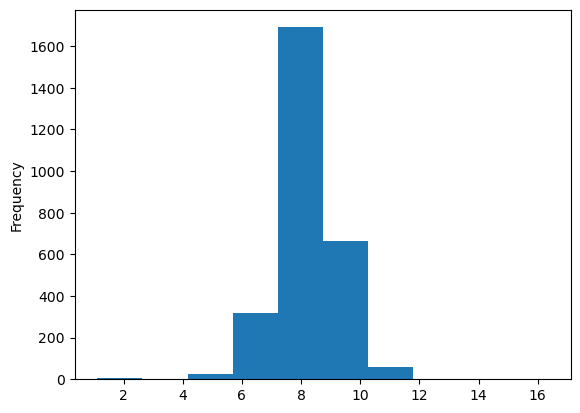

distributedPercentage


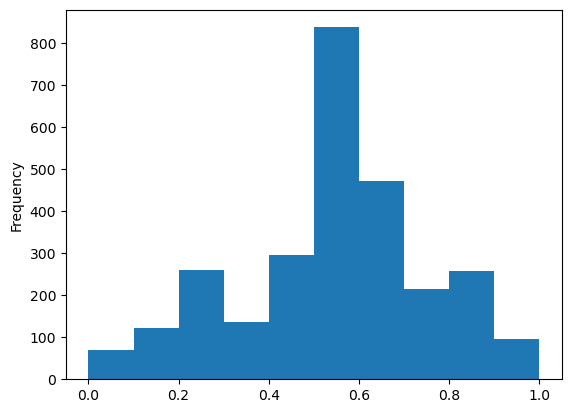

In [35]:
for x in num_col:
    print(df.columns[x])
    df.iloc[:,x].plot.hist()
    plt.show()

## Null Values

In [36]:
df.isna().sum()

ID                         0
success                    0
brandSlogan                0
hasVideo                   0
rating                     0
priceUSD                 179
countryRegion             71
startDate                  0
endDate                    0
teamSize                 154
hasGithub                  0
hasReddit                  0
platform                   0
coinNum                    0
minInvestment              0
distributedPercentage      0
dtype: int64

In [37]:
df.fillna(value={'countryRegion':'Unknown'},inplace=True)

In [38]:
df.countryRegion.isna().sum()

0

In [39]:
df.isna().sum(axis=0).sum()

333

In [40]:
df1=df.fillna(value={'priceUSD':-1,'teamSize':-1})

In [41]:
df1['priceUSD_null']=df.priceUSD.isna()

In [42]:
df1['teamSize_null']=df.teamSize.isna()

In [43]:
df.isna().sum().sum()

333

In [44]:
df.dropna(inplace=True)

In [45]:
df.drop(columns=['ID','brandSlogan','startDate','endDate'],inplace=True)
df1.drop(columns=['ID','brandSlogan','startDate','endDate'],inplace=True)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2437 entries, 0 to 2752
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   success                2437 non-null   int64  
 1   hasVideo               2437 non-null   int64  
 2   rating                 2437 non-null   float64
 3   priceUSD               2437 non-null   float64
 4   countryRegion          2437 non-null   object 
 5   teamSize               2437 non-null   float64
 6   hasGithub              2437 non-null   int64  
 7   hasReddit              2437 non-null   int64  
 8   platform               2437 non-null   object 
 9   coinNum                2437 non-null   float64
 10  minInvestment          2437 non-null   int64  
 11  distributedPercentage  2437 non-null   float64
dtypes: float64(5), int64(5), object(2)
memory usage: 247.5+ KB


In [47]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2761 entries, 0 to 2766
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   success                2761 non-null   int64  
 1   hasVideo               2761 non-null   int64  
 2   rating                 2761 non-null   float64
 3   priceUSD               2761 non-null   float64
 4   countryRegion          2761 non-null   object 
 5   teamSize               2761 non-null   float64
 6   hasGithub              2761 non-null   int64  
 7   hasReddit              2761 non-null   int64  
 8   platform               2761 non-null   object 
 9   coinNum                2761 non-null   float64
 10  minInvestment          2761 non-null   int64  
 11  distributedPercentage  2761 non-null   float64
 12  priceUSD_null          2761 non-null   bool   
 13  teamSize_null          2761 non-null   bool   
dtypes: bool(2), float64(5), int64(5), object(2)
memory usage: 350

## Categorical

In [48]:
platforms=pd.Series(df['platform'].unique())

In [49]:
platforms.str.contains('eth').value_counts()

False    114
Name: count, dtype: int64

In [50]:
def categorical_analysis(df1,x):
    cat_df1=pd.DataFrame(df1.groupby(by=x).success.sum()*100/df1.groupby(by=x).success.count())
    cat_df2=pd.DataFrame(df1.groupby(by=x).success.count())
    cat_df1=cat_df1.rename(columns={'success':'rate'})
    cat_df1=cat_df1.merge(cat_df2,on=x)
    cat_df1=cat_df1.rename(columns={'success':'count'})
    return cat_df1

In [51]:
print(categorical_analysis(df,'platform').sort_values(by='count',ascending=False).to_string())

                                   rate  count
platform                                      
Ethereum                      39.923591   2094
Waves                         30.612245     49
Stellar                       27.027027     37
Separate blockchain           51.851852     27
NEO                           47.368421     19
Ethereum                      10.526316     19
EOS                           35.714286     14
Ethereum                      15.384615     13
NEM                           25.000000     12
X11                           16.666667      6
Scrypt                        40.000000      5
Separate Blockchain           40.000000      5
Bitcoin                        0.000000      5
Graphene                      75.000000      4
Ethereum                      50.000000      4
                              25.000000      4
ICON                          66.666667      3
BTC                            0.000000      3
Komodo                        66.666667      3
NXT          

In [52]:
x=pd.Series(df.platform.unique())
y=x.str.contains('eth',case=False)
eth=x[y[y==True].index].values
df.platform.replace(eth,'Ethereum',inplace=True)

In [53]:
platform_combine=categorical_analysis(df,'platform').sort_values(by='count',ascending=False)
platform_replace1=platform_combine[(platform_combine['count']<2) & (platform_combine['rate']!=100)].index
df['platform'].replace(platform_replace1,'Others1',inplace=True)
platform_replace2=platform_combine[(platform_combine['count']<3) & (platform_combine['rate']!=100)].index
df['platform'].replace(platform_replace2,'Others2',inplace=True)

In [54]:
platform_combine=categorical_analysis(df1,'platform').sort_values(by='count',ascending=False)
platform_replace1=platform_combine[(platform_combine['count']<2) & (platform_combine['rate']!=100)].index
df1['platform'].replace(platform_replace1,'Others1',inplace=True)
platform_replace2=platform_combine[(platform_combine['count']<3) & (platform_combine['rate']!=100)].index
df1['platform'].replace(platform_replace2,'Others2',inplace=True)

In [55]:
print(len(df.platform.unique()), len(df1.platform.unique()))

48 59


In [56]:
countryRegion_correction={'Curaçao':'Curacao','México':'Mexico','india':'India','usa':'USA','SINGAPORE':'Singapore'}

In [57]:
df['countryRegion'].replace(countryRegion_correction,inplace=True)
df1['countryRegion'].replace(countryRegion_correction,inplace=True)

In [58]:
print(categorical_analysis(df,'countryRegion').sort_values(by='count',ascending=False).to_string())

                                        rate  count
countryRegion                                      
Singapore                          49.640288    278
USA                                30.350195    257
UK                                 38.247012    251
Estonia                            47.674419    172
Russia                             36.434109    129
Switzerland                        50.400000    125
Cayman Islands                     54.237288     59
Germany                            35.185185     54
Netherlands                        32.692308     52
Malta                              40.384615     52
Unknown                            12.000000     50
Australia                          36.734694     49
British Virgin Islands             45.454545     44
Canada                             33.333333     42
France                             41.463415     41
India                              30.555556     36
United Arab Emirates               50.000000     34
Gibraltar   

In [59]:
cR_combine=categorical_analysis(df,'countryRegion').sort_values(by='count',ascending=False)
cR_replace1=cR_combine[(cR_combine['count']<7) & (cR_combine['rate']!=100)].index
df['countryRegion'].replace(cR_replace1,'Others1',inplace=True)
cR_replace2=cR_combine[(cR_combine['count']<6) & (cR_combine['rate']==100)].index
df['countryRegion'].replace(cR_replace2,'Others2',inplace=True)

In [60]:
cR_combine=categorical_analysis(df1,'countryRegion').sort_values(by='count',ascending=False)
cR_replace1=cR_combine[(cR_combine['count']<7) & (cR_combine['rate']!=100)].index
df1['countryRegion'].replace(cR_replace1,'Others1',inplace=True)
cR_replace2=cR_combine[(cR_combine['count']<6) & (cR_combine['rate']==100)].index
df1['countryRegion'].replace(cR_replace2,'Others2',inplace=True)

In [61]:
print(len(df.countryRegion.unique()),len(df.countryRegion.unique()))

58 58


<Axes: >

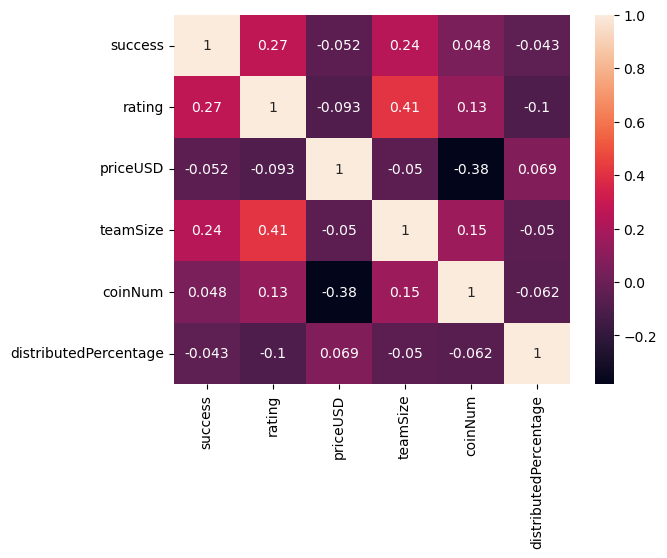

In [62]:
sns.heatmap(df.iloc[:,[0,2,3,5,9,11]].corr(),annot=True)

df_slogan=pd.DataFrame()
df_slogan['ID']=df['ID']
df_slogan['text_length']=df['brandSlogan'].str.len()
df_slogan['avg_word_length']=df['brandSlogan'].apply(
        lambda x: np.mean([len(word) for word in x.split()]) if x.split() else 0
    )
df_slogan['word_count']=df['brandSlogan'].apply(lambda x: len(word_tokenize(x)))
df_slogan['sentence_count']=df['brandSlogan'].apply(lambda x: len(sent_tokenize(x)))

df_slogan.describe()

from google import genai
from google.genai import types
slogan_embeddings=[]
client = genai.Client()
for i in range(0,df.shape[0],100):
    result = client.models.embed_content(
            model="text-embedding-004",
            contents= df.iloc[i:i+100,2].to_list(),
            config=types.EmbedContentConfig(output_dimensionality=128))
    slogan_embeddings.append(np.array(result.embeddings))
    

## One Hot Encoding

In [63]:
df_f=pd.get_dummies(df,columns=['platform','countryRegion'])
df_f1=pd.get_dummies(df1,columns=['platform','countryRegion'])

In [64]:
print(df_f1.shape, df_f.shape)

(2761, 131) (2437, 116)


## Undersampling

In [65]:
def my_SVC_poly_us(df,c=1,d=4):
    X=df[df.columns[1:]]
    Y=df[df.columns[0]]
    rus=RandomUnderSampler(random_state=42)
    X_us,Y_us=rus.fit_resample(X,Y)
    X_train_us, X_test, Y_train_us, Y_test = train_test_split(X_us, Y_us, test_size=0.2, random_state=42)
    #X_train_us,Y_train_us=rus.fit_resample(X_train,Y_train)
    print(X_train_us.shape,Y_train_us.shape, Y_train_us.value_counts())
    model=SVC(C=c,kernel='poly',degree=d,class_weight='balanced',probability=True)
    model=model.fit(X_train_us,Y_train_us)
    Y_pred=model.predict(X_test)
    print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
    print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
    print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))

In [66]:
my_SVC_poly_us(df_f1)

(1643, 130) (1643,) success
0    828
1    815
Name: count, dtype: int64
Accuracy:  0.5815085158150851
Confusion Matrix:
 [[143  56]
 [116  96]]
PRFC:
 (array([0.55212355, 0.63157895]), array([0.71859296, 0.45283019]), array([0.62445415, 0.52747253]), array([199, 212], dtype=int64))
